<a href="https://colab.research.google.com/github/Seetal-0903/AI-Driven-Cybersecurity-Threat-Prediction-Platform/blob/main/Python_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Calculator**

In [ ]:
def calculator():
    """A simple calculator that performs basic arithmetic operations."""
    print("Simple Calculator")
    print("Operations: +, -, *, /\n")

    while True:
        try:
            num1 = float(input("Enter first number: "))
            operator = input("Enter operator (+, -, *, /): ")
            num2 = float(input("Enter second number: "))
        except ValueError:
            print("Invalid input. Please enter numbers.")
            continue

        result = None
        if operator == '+':
            result = num1 + num2
        elif operator == '-':
            result = num1 - num2
        elif operator == '*':
            result = num1 * num2
        elif operator == '/':
            if num2 == 0:
                print("Error: Division by zero is not allowed.")
                continue
            result = num1 / num2
        else:
            print("Invalid operator. Please use +, -, *, or /.")
            continue

        print(f"Result: {num1} {operator} {num2} = {result}")

        another_calculation = input("Do you want to perform another calculation? (yes/no): ").lower()
        if another_calculation != 'yes':
            break

# To run the calculator, uncomment the line below:
calculator()

Simple Calculator
Operations: +, -, *, /

Enter first number: 1
Enter operator (+, -, *, /): +
Enter second number: 2
Result: 1.0 + 2.0 = 3.0
Do you want to perform another calculation? (yes/no): yes
Enter first number: 1
Enter operator (+, -, *, /): +
Enter second number: 2
Result: 1.0 + 2.0 = 3.0
Do you want to perform another calculation? (yes/no): no


## Simulate/Load Cybersecurity Data




In [3]:
import pandas as pd
import numpy as np

print("Libraries pandas and numpy imported successfully.")

Libraries pandas and numpy imported successfully.


In [5]:
num_records = 1000

timestamps = pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_records, freq='s'))

# Generate IPs
source_ips = ['192.168.1.' + str(i) for i in np.random.randint(1, 255, num_records)]
destination_ips = ['10.0.0.' + str(i) for i in np.random.randint(1, 255, num_records)]

# Generate common ports and some unusual ones
common_ports = [80, 443, 22, 21, 23, 53, 3389]
unusual_ports = [np.random.randint(49152, 65535) for _ in range(num_records // 20)] # ~5% unusual ports
ports = np.random.choice(common_ports, num_records - len(unusual_ports)).tolist() + unusual_ports
np.random.shuffle(ports)

protocols = np.random.choice(['TCP', 'UDP', 'ICMP'], num_records, p=[0.7, 0.2, 0.1])

bytes_sent = np.random.randint(50, 5000, num_records)
bytes_received = np.random.randint(50, 10000, num_records)
duration_seconds = np.random.uniform(1, 300, num_records)

statuses = np.random.choice(['success', 'failure', 'timeout'], num_records, p=[0.85, 0.1, 0.05])

data = {
    'timestamp': timestamps,
    'source_ip': source_ips,
    'destination_ip': destination_ips,
    'port': ports,
    'protocol': protocols,
    'bytes_sent': bytes_sent,
    'bytes_received': bytes_received,
    'duration_seconds': duration_seconds,
    'status': statuses
}

df_cybersecurity = pd.DataFrame(data)

# Introduce anomalies

# Anomaly 1: High bytes_sent for a few records
anomaly_indices_bytes = np.random.choice(df_cybersecurity.index, size=10, replace=False)
df_cybersecurity.loc[anomaly_indices_bytes, 'bytes_sent'] = np.random.randint(100000, 1000000, size=10)
df_cybersecurity.loc[anomaly_indices_bytes, 'status'] = 'failure' # Often high traffic means failure/attack

# Anomaly 2: Very short duration for a failed connection (e.g., port scan attempt)
anomaly_indices_duration = np.random.choice(df_cybersecurity[df_cybersecurity['status'] == 'failure'].index, size=10, replace=False)
df_cybersecurity.loc[anomaly_indices_duration, 'duration_seconds'] = np.random.uniform(0.1, 1.0, size=10)

# Anomaly 3: Unusual port usage combined with high bytes_sent/received
anomaly_indices_port_traffic = np.random.choice(df_cybersecurity.index, size=10, replace=False)
df_cybersecurity.loc[anomaly_indices_port_traffic, 'port'] = np.random.randint(1024, 49151, size=10) # Uncommon ports
df_cybersecurity.loc[anomaly_indices_port_traffic, 'bytes_sent'] = np.random.randint(50000, 500000, size=10)
df_cybersecurity.loc[anomaly_indices_port_traffic, 'bytes_received'] = np.random.randint(50000, 500000, size=10)
df_cybersecurity.loc[anomaly_indices_port_traffic, 'status'] = 'failure'

print("Generated synthetic cybersecurity dataset with normal and anomalous patterns.")
print("First 5 rows of df_cybersecurity:")
print(df_cybersecurity.head())
print("\nInformation about df_cybersecurity:")
df_cybersecurity.info()

Generated synthetic cybersecurity dataset with normal and anomalous patterns.
First 5 rows of df_cybersecurity:
            timestamp      source_ip destination_ip  port protocol  \
0 2023-01-01 00:00:00  192.168.1.137      10.0.0.58    23      UDP   
1 2023-01-01 00:00:01  192.168.1.155      10.0.0.81    53      TCP   
2 2023-01-01 00:00:02   192.168.1.10      10.0.0.70    22     ICMP   
3 2023-01-01 00:00:03   192.168.1.33       10.0.0.2   443      TCP   
4 2023-01-01 00:00:04   192.168.1.78      10.0.0.10    23      TCP   

   bytes_sent  bytes_received  duration_seconds   status  
0        4755             286        284.991385  success  
1        2562            3472         52.441397  success  
2         920            1569        290.577087  success  
3        2294            5067         59.170359  success  
4        3895            3590        157.382947  success  

Information about df_cybersecurity:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Dat

## Preprocess Data and Feature Engineer




In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical features
categorical_features = ['protocol', 'status']
numerical_features = ['bytes_sent', 'bytes_received', 'duration_seconds', 'port']

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop' # Change from 'passthrough' to 'drop' to exclude untransformed columns
)

# Apply the preprocessing
# We'll create a temporary DataFrame for the preprocessed data first
df_processed_array = preprocessor.fit_transform(df_cybersecurity)

# Get feature names after one-hot encoding for categorical features
one_hot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine all feature names
processed_feature_names = numerical_features + list(one_hot_features)

# Create the final processed DataFrame
df_processed_cybersecurity = pd.DataFrame(df_processed_array, columns=processed_feature_names)

print("Generated df_processed_cybersecurity with preprocessed features.")
print("First 5 rows of df_processed_cybersecurity:")
print(df_processed_cybersecurity.head())
print("\nInformation about df_processed_cybersecurity:")
df_processed_cybersecurity.info()

Generated df_processed_cybersecurity with preprocessed features.
First 5 rows of df_processed_cybersecurity:
   bytes_sent  bytes_received  duration_seconds      port  protocol_ICMP  \
0   -0.084539       -0.238110          1.571228 -0.290451            0.0   
1   -0.120120       -0.132989         -1.121649 -0.288087            0.0   
2   -0.146761       -0.195778          1.635910 -0.290530            1.0   
3   -0.124468       -0.080363         -1.043729 -0.257349            0.0   
4   -0.098492       -0.129096          0.093551 -0.290451            0.0   

   protocol_TCP  protocol_UDP  status_failure  status_success  status_timeout  
0           0.0           1.0             0.0             1.0             0.0  
1           1.0           0.0             0.0             1.0             0.0  
2           0.0           0.0             0.0             1.0             0.0  
3           1.0           0.0             0.0             1.0             0.0  
4           1.0           0.0     

## Select and Train AI Model for Anomaly Detection




In [8]:
from sklearn.ensemble import IsolationForest

# Make a copy of the original DataFrame to store anomaly results
df_cybersecurity_with_anomalies = df_cybersecurity.copy()

# Instantiate Isolation Forest model
# contamination is set to 0.05, meaning we expect 5% of the data to be anomalies
# random_state is set for reproducibility
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the model to the processed data
iso_forest.fit(df_processed_cybersecurity)

# Predict anomaly scores
# Lower scores indicate a higher likelihood of being an anomaly
df_cybersecurity_with_anomalies['anomaly_score'] = iso_forest.decision_function(df_processed_cybersecurity)

# Predict anomaly labels
# -1 for outliers (anomalies), 1 for inliers (normal)
df_cybersecurity_with_anomalies['anomaly_prediction'] = iso_forest.predict(df_processed_cybersecurity)

print("Isolation Forest model trained and anomaly scores/predictions added to 'df_cybersecurity_with_anomalies'.")
print("First 5 rows with anomaly scores and predictions:")
print(df_cybersecurity_with_anomalies.head())
print("\nAnomaly prediction value counts:")
print(df_cybersecurity_with_anomalies['anomaly_prediction'].value_counts())

Isolation Forest model trained and anomaly scores/predictions added to 'df_cybersecurity_with_anomalies'.
First 5 rows with anomaly scores and predictions:
            timestamp      source_ip destination_ip  port protocol  \
0 2023-01-01 00:00:00  192.168.1.137      10.0.0.58    23      UDP   
1 2023-01-01 00:00:01  192.168.1.155      10.0.0.81    53      TCP   
2 2023-01-01 00:00:02   192.168.1.10      10.0.0.70    22     ICMP   
3 2023-01-01 00:00:03   192.168.1.33       10.0.0.2   443      TCP   
4 2023-01-01 00:00:04   192.168.1.78      10.0.0.10    23      TCP   

   bytes_sent  bytes_received  duration_seconds   status  anomaly_score  \
0        4755             286        284.991385  success       0.100001   
1        2562            3472         52.441397  success       0.234151   
2         920            1569        290.577087  success       0.051754   
3        2294            5067         59.170359  success       0.222249   
4        3895            3590        157.382947 

## Implement Threat Detection and Scoring



In [9]:
df_threats = df_cybersecurity_with_anomalies[df_cybersecurity_with_anomalies['anomaly_prediction'] == -1].copy()

print("Detected threats (anomalies) stored in 'df_threats'.")
print("First 10 rows of detected threats:")
print(df_threats.head(10))

Detected threats (anomalies) stored in 'df_threats'.
First 10 rows of detected threats:
              timestamp      source_ip destination_ip   port protocol  \
23  2023-01-01 00:00:23    192.168.1.4     10.0.0.118     53      UDP   
105 2023-01-01 00:01:45    192.168.1.6      10.0.0.35  56409      UDP   
113 2023-01-01 00:01:53  192.168.1.243      10.0.0.63     23      UDP   
127 2023-01-01 00:02:07  192.168.1.103     10.0.0.206     80     ICMP   
129 2023-01-01 00:02:09  192.168.1.135     10.0.0.200  49109      TCP   
141 2023-01-01 00:02:21  192.168.1.228      10.0.0.61     22      UDP   
146 2023-01-01 00:02:26   192.168.1.40      10.0.0.72     22      TCP   
150 2023-01-01 00:02:30   192.168.1.31     10.0.0.178     21      UDP   
177 2023-01-01 00:02:57   192.168.1.28      10.0.0.39  46479      TCP   
226 2023-01-01 00:03:46  192.168.1.171     10.0.0.108     22      TCP   

     bytes_sent  bytes_received  duration_seconds   status  anomaly_score  \
23         4124            8726

Descriptive statistics for anomaly scores of detected threats:
count    50.000000
mean     -0.043646
std       0.037150
min      -0.138641
25%      -0.065330
50%      -0.032081
75%      -0.014445
max      -0.000135
Name: anomaly_score, dtype: float64


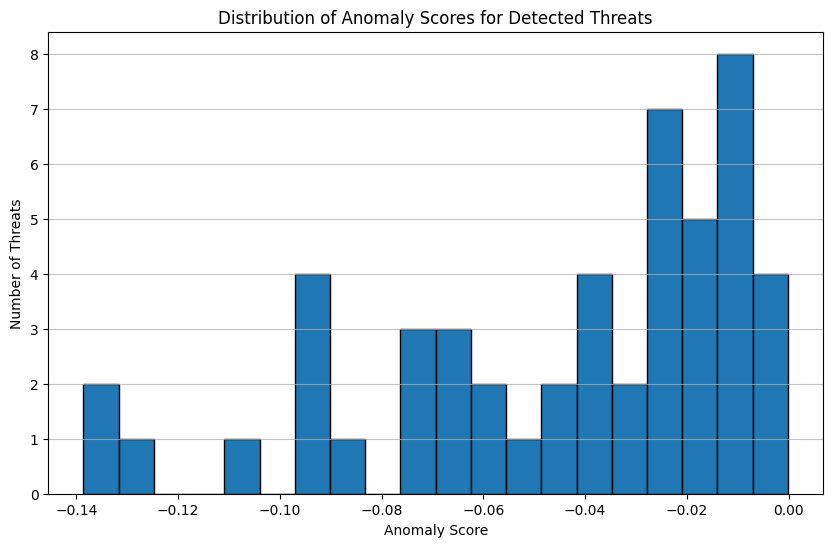

In [10]:
import matplotlib.pyplot as plt

print("Descriptive statistics for anomaly scores of detected threats:")
print(df_threats['anomaly_score'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df_threats['anomaly_score'], bins=20, edgecolor='black')
plt.title('Distribution of Anomaly Scores for Detected Threats')
plt.xlabel('Anomaly Score')
plt.ylabel('Number of Threats')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [11]:
min_score = df_threats['anomaly_score'].min()
max_score = df_threats['anomaly_score'].max()

# Define thresholds based on the score distribution. For Isolation Forest, lower scores mean higher anomaly.
# We'll invert the logic for threat levels: more negative score = higher threat.
# Let's say, bottom 25% are High, next 25% are Medium, rest are Low. This is an example, thresholds can be adjusted.
# More appropriately, we can use quantiles or fixed ranges if domain knowledge is available.

# Using quantiles as an example for dynamic thresholding based on detected anomalies
threshold_high = df_threats['anomaly_score'].quantile(0.25) # e.g., scores below this are 'High'
threshold_medium = df_threats['anomaly_score'].quantile(0.50) # e.g., scores between this and high are 'Medium'

# Or, using fixed ranges based on general understanding of Isolation Forest scores, which are often between -0.5 and 0.5
# For Isolation Forest, a score close to -1 indicates a strong anomaly, and close to 0 indicates normal.
# Since our scores are already mostly negative, we can define levels based on magnitude.
# For example, let's consider relative position or absolute values based on the observed range.

def assign_threat_level(score):
    if score <= threshold_high: # More negative scores are higher threat
        return 'High'
    elif score <= threshold_medium:
        return 'Medium'
    else:
        return 'Low'

df_threats['threat_level'] = df_threats['anomaly_score'].apply(assign_threat_level)

print("Threat levels categorized and added to 'df_threats'.")
print("Threat level distribution:")
print(df_threats['threat_level'].value_counts())
print("\nFirst 10 rows of df_threats with threat levels:")
print(df_threats.head(10))

Threat levels categorized and added to 'df_threats'.
Threat level distribution:
threat_level
Low       25
High      13
Medium    12
Name: count, dtype: int64

First 10 rows of df_threats with threat levels:
              timestamp      source_ip destination_ip   port protocol  \
23  2023-01-01 00:00:23    192.168.1.4     10.0.0.118     53      UDP   
105 2023-01-01 00:01:45    192.168.1.6      10.0.0.35  56409      UDP   
113 2023-01-01 00:01:53  192.168.1.243      10.0.0.63     23      UDP   
127 2023-01-01 00:02:07  192.168.1.103     10.0.0.206     80     ICMP   
129 2023-01-01 00:02:09  192.168.1.135     10.0.0.200  49109      TCP   
141 2023-01-01 00:02:21  192.168.1.228      10.0.0.61     22      UDP   
146 2023-01-01 00:02:26   192.168.1.40      10.0.0.72     22      TCP   
150 2023-01-01 00:02:30   192.168.1.31     10.0.0.178     21      UDP   
177 2023-01-01 00:02:57   192.168.1.28      10.0.0.39  46479      TCP   
226 2023-01-01 00:03:46  192.168.1.171     10.0.0.108     22   

## Alerting and Visualization Mechanism




In [12]:
print("--- Threat Alerts ---")
for index, row in df_threats.iterrows():
    print(f"Alert: Detected {row['threat_level']} threat!")
    print(f"  Timestamp: {row['timestamp']}")
    print(f"  Source IP: {row['source_ip']}")
    print(f"  Destination IP: {row['destination_ip']}")
    print(f"  Port: {row['port']}")
    print(f"  Protocol: {row['protocol']}")
    print(f"  Anomaly Score: {row['anomaly_score']:.4f}")
    print(f"  Threat Level: {row['threat_level']}")
    print("----------------------")


--- Threat Alerts ---
Alert: Detected Low threat!
  Timestamp: 2023-01-01 00:00:23
  Source IP: 192.168.1.4
  Destination IP: 10.0.0.118
  Port: 53
  Protocol: UDP
  Anomaly Score: -0.0103
  Threat Level: Low
----------------------
Alert: Detected Medium threat!
  Timestamp: 2023-01-01 00:01:45
  Source IP: 192.168.1.6
  Destination IP: 10.0.0.35
  Port: 56409
  Protocol: UDP
  Anomaly Score: -0.0634
  Threat Level: Medium
----------------------
Alert: Detected Medium threat!
  Timestamp: 2023-01-01 00:01:53
  Source IP: 192.168.1.243
  Destination IP: 10.0.0.63
  Port: 23
  Protocol: UDP
  Anomaly Score: -0.0498
  Threat Level: Medium
----------------------
Alert: Detected Low threat!
  Timestamp: 2023-01-01 00:02:07
  Source IP: 192.168.1.103
  Destination IP: 10.0.0.206
  Port: 80
  Protocol: ICMP
  Anomaly Score: -0.0225
  Threat Level: Low
----------------------
Alert: Detected High threat!
  Timestamp: 2023-01-01 00:02:09
  Source IP: 192.168.1.135
  Destination IP: 10.0.0.200
  

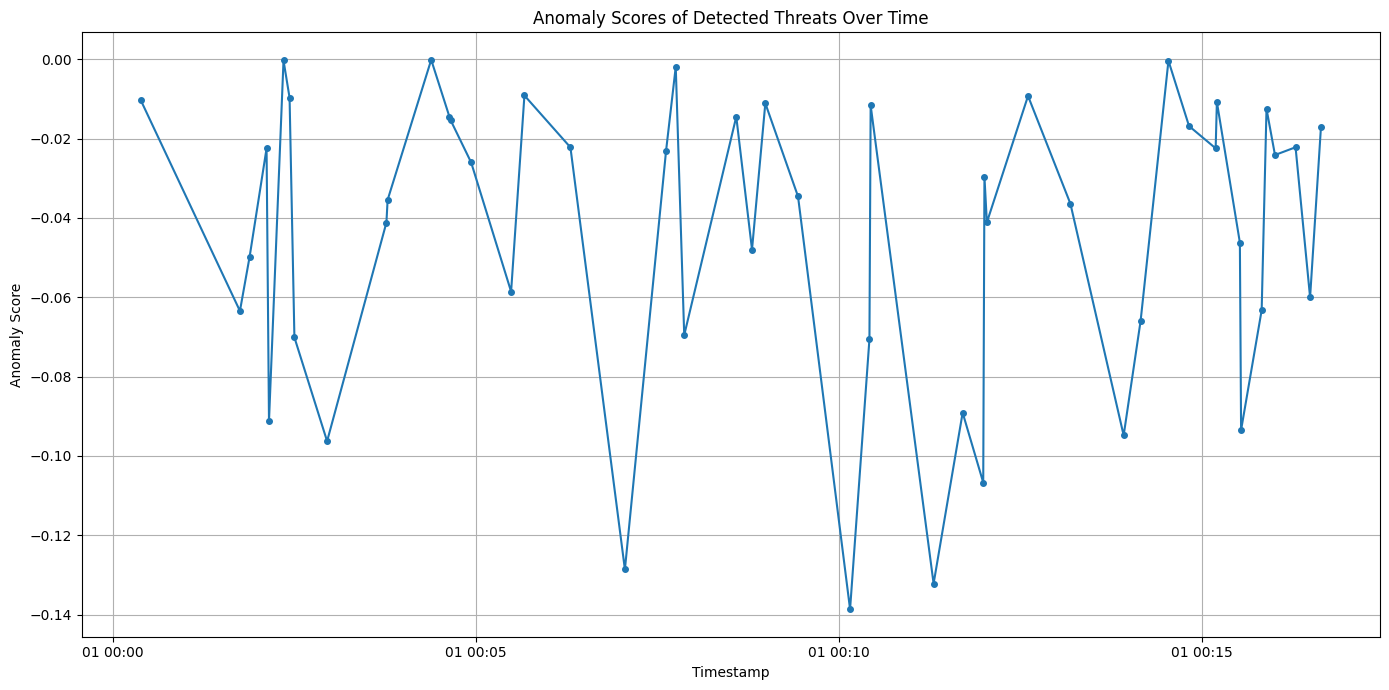

In [13]:
plt.figure(figsize=(14, 7))
plt.plot(df_threats['timestamp'], df_threats['anomaly_score'], marker='o', linestyle='-', markersize=4)
plt.title('Anomaly Scores of Detected Threats Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Anomaly Score')
plt.grid(True)
plt.tight_layout()
plt.show()


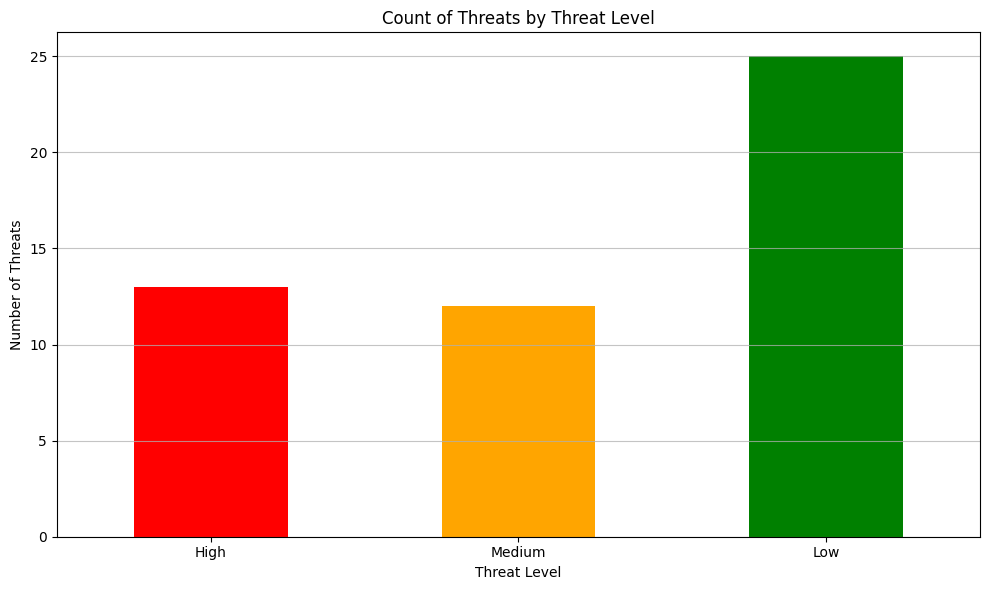

In [14]:
threat_level_counts = df_threats['threat_level'].value_counts().reindex(['High', 'Medium', 'Low'])

plt.figure(figsize=(10, 6))
threat_level_counts.plot(kind='bar', color=['red', 'orange', 'green'])
plt.title('Count of Threats by Threat Level')
plt.xlabel('Threat Level')
plt.ylabel('Number of Threats')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()